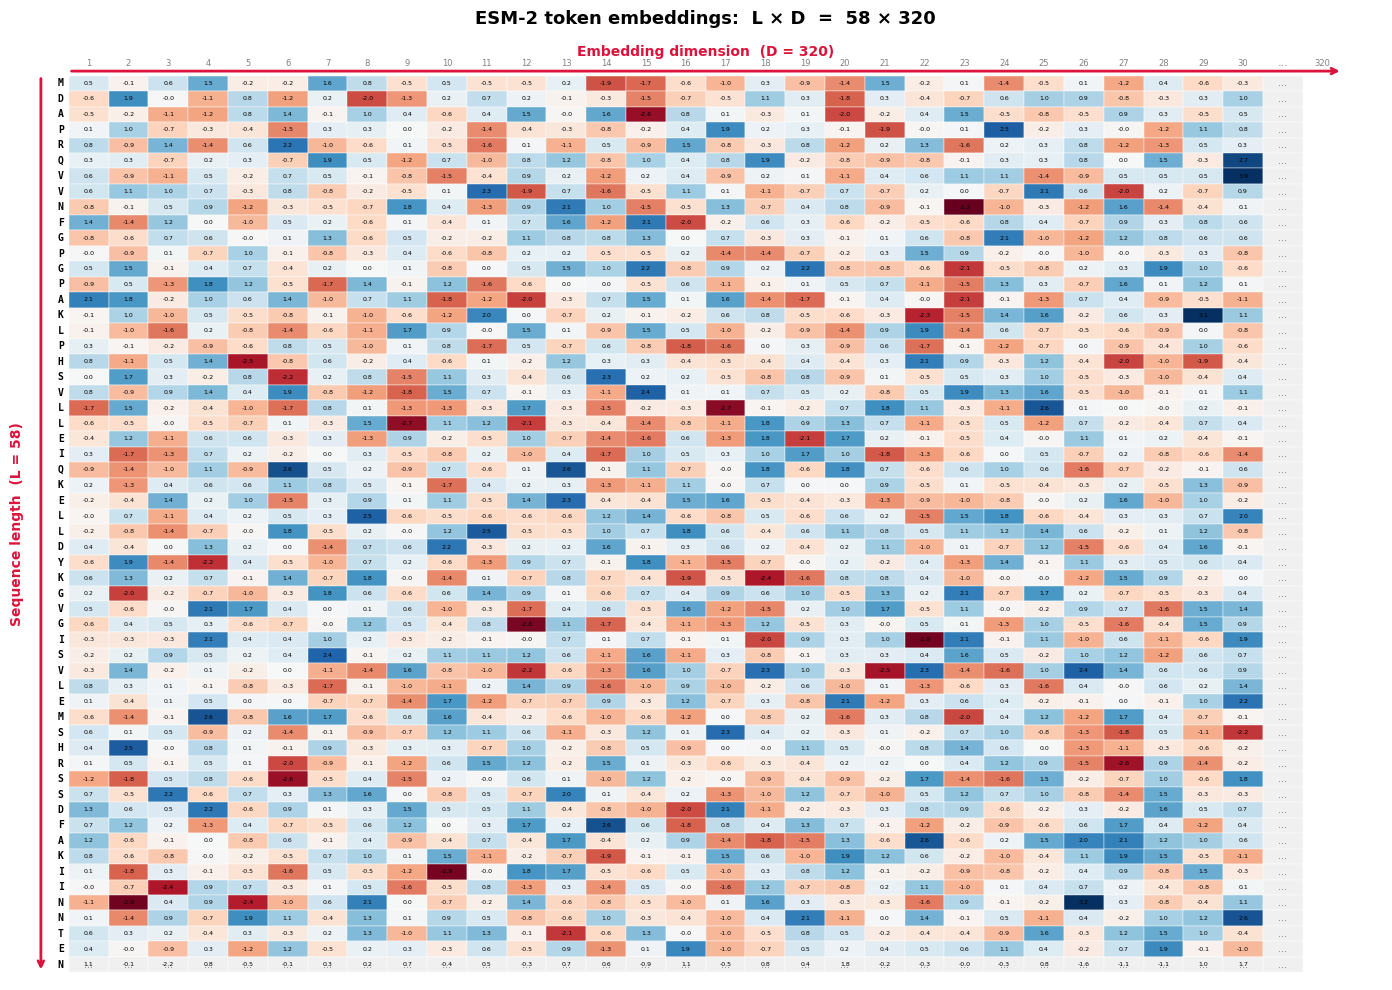

L = 58 residues,  D = 320 dimensions


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sequence = "MDAPRQVVNFGPGPAKLPHSVLLEIQKELLDYKGVGISVLEMSHRSSDFAKIINNTEN"
L = len(sequence)
D = 320  # embedding dimension

# Generate L x 30 random numbers to display (last col = ...)
np.random.seed(42)
data_display = np.random.randn(L, 30)

fig, ax = plt.subplots(figsize=(14, 10))

# ── Column headers: first 30 dims + "..." ─────────────────────────────────────
for j in range(30):
    ax.text(j + 1.5, L + 0.8, str(j+1),
            ha='center', va='center', fontsize=6, color='gray')
ax.text(31.5, L + 0.8, '...',
        ha='center', va='center', fontsize=8, color='gray')
ax.text(32.5, L + 0.8, '320',
        ha='center', va='center', fontsize=6, color='gray')

# ── Row headers: amino acid letters ───────────────────────────────────────────
for i, aa in enumerate(sequence):
    ax.text(0.8, L - i - 0.5, aa,
            ha='center', va='center', fontsize=7,
            fontfamily='monospace', fontweight='bold')

# ── Cell values: L x 30 ───────────────────────────────────────────────────────
for i in range(L):
    for j in range(30):
        val = data_display[i, j]
        # color by value
        color = plt.cm.RdBu((val + 3) / 6)
        ax.add_patch(plt.Rectangle(
            (j + 1, L - i - 1), 1, 1,
            facecolor=color, edgecolor='white', linewidth=0.3
        ))
        ax.text(j + 1.5, L - i - 0.5, f'{val:.1f}',
                ha='center', va='center', fontsize=4.5, color='black')

    # "..." column
    ax.add_patch(plt.Rectangle(
        (31, L - i - 1), 1, 1,
        facecolor='#f0f0f0', edgecolor='white', linewidth=0.3
    ))
    ax.text(31.5, L - i - 0.5, '...',
            ha='center', va='center', fontsize=7, color='gray')

    # last row special case: all "..."
    if i == L - 1:
        for j in range(30):
            ax.add_patch(plt.Rectangle(
                (j + 1, 0), 1, 1,
                facecolor='#f0f0f0', edgecolor='white', linewidth=0.3
            ))
            ax.text(j + 1.5, 0.5, '...',
                    ha='center', va='center', fontsize=7, color='gray')

# ── Dimension label arrow (x axis) ───────────────────────────────────────────
ax.annotate('', xy=(33, L + 0.3), xytext=(1, L + 0.3),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
ax.text(17, L + 1.3, 'Embedding dimension  (D = 320)',
        ha='center', fontsize=10, color='crimson', fontweight='bold')

# ── Sequence length arrow (y axis) ───────────────────────────────────────────
ax.annotate('', xy=(0.3, 0), xytext=(0.3, L),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
ax.text(-0.3, L / 2, f'Sequence length  (L = {L})',
        ha='center', va='center', fontsize=10, color='crimson',
        fontweight='bold', rotation=90)

ax.set_xlim(0, 34)
ax.set_ylim(-0.5, L + 2)
ax.axis('off')
ax.set_title(f'ESM-2 token embeddings:  L × D  =  {L} × 320',
             fontsize=13, pad=15, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/embedding_sketch.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"L = {L} residues,  D = 320 dimensions")